# Notebook 04 : évaluation clinique et interprétabilité

Le Notebook 03 a sélectionné le meilleur modèle sur le jeu de validation et l'a sauvegardé dans `models/best_model.pt`. Ce notebook charge ce modèle et l'évalue **une seule fois, sur le jeu de test mis de côté, qu'il n'a jamais vu pendant l'entraînement ni pendant la sélection**.

Le résultat est présenté dans les termes qui comptent pour un outil d'aide au diagnostic : pas seulement l'accuracy, mais la sensibilité, la spécificité, les valeurs prédictives, et un premier regard sur ce à quoi le modèle réagit dans chaque image. Il se termine par une discussion de la valeur médicale et opérationnelle, des limites, et des recommandations.

## 1. Configuration et chargement du modèle

In [1]:
import ssl
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import Markdown, display
from PIL import Image
from malaria_evaluation import patient_bootstrap_ci
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

try:
    import certifi

    _certifi_bundle = certifi.where()
    _original_load_default_certs = ssl.SSLContext.load_default_certs

    def _patched_load_default_certs(self, purpose=ssl.Purpose.SERVER_AUTH):
        try:
            self.load_verify_locations(cafile=_certifi_bundle)
        except Exception:
            _original_load_default_certs(self, purpose)

    ssl.SSLContext.load_default_certs = _patched_load_default_certs
except Exception:
    pass

sns.set_theme(style="whitegrid")
torch.manual_seed(42)

DEVICE = torch.device("cpu")
PROJECT_ROOT = Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

checkpoint = torch.load(MODELS_DIR / "best_model.pt", map_location=DEVICE, weights_only=False)
print(f"Checkpoint chargé : architecture={checkpoint['architecture']}, "
      f"val_accuracy={checkpoint['val_accuracy']:.4f}, val_f1_parasitized={checkpoint['val_f1_parasitized']:.4f}")

IMG_SIZE = checkpoint["img_size"]
IMAGENET_MEAN = checkpoint["imagenet_mean"]
IMAGENET_STD = checkpoint["imagenet_std"]
LABEL_TO_IDX = checkpoint["label_to_idx"]
IDX_TO_LABEL = {v: k for k, v in LABEL_TO_IDX.items()}
POS_IDX = LABEL_TO_IDX["Parasitized"]  # classe positive pour les metriques cliniques

Checkpoint chargé : architecture=simple_cnn, val_accuracy=0.9685, val_f1_parasitized=0.9634


In [2]:
class SimpleCNN(nn.Module):
    '''Même architecture que dans le Notebook 03.'''

    def __init__(self, num_classes: int = 2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def build_resnet18_transfer(num_classes: int = 2) -> nn.Module:
    net = models.resnet18(weights=None)  # poids ecrases juste apres par le state_dict du checkpoint
    net.fc = nn.Linear(net.fc.in_features, num_classes)
    return net


if checkpoint["architecture"] == "simple_cnn":
    model = SimpleCNN()
else:
    model = build_resnet18_transfer()

model.load_state_dict(checkpoint["state_dict"])
model.to(DEVICE)
model.eval()
print(f"Modèle prêt : {checkpoint['architecture']}")

Modèle prêt : simple_cnn


## 2. Jeu de test et inférence

In [3]:
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class MalariaCellDataset(Dataset):
    def __init__(self, manifest_df: pd.DataFrame, root_dir: Path, transform=None):
        self.df = manifest_df.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.root_dir / row["path"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, LABEL_TO_IDX[row["label"]]


test_df = pd.read_csv(PROCESSED_DIR / "test.csv")
test_dataset = MalariaCellDataset(test_df, PROJECT_ROOT, transform=eval_transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

print(f"Jeu de test : {len(test_dataset):,} images (jamais utilisées dans les Notebooks 02/03 pour l'entraînement ou la sélection de modèle)")
test_df["label"].value_counts()

Jeu de test : 4,020 images (jamais utilisées dans les Notebooks 02/03 pour l'entraînement ou la sélection de modèle)


label
Uninfected     2048
Parasitized    1972
Name: count, dtype: int64

In [4]:
all_probs, all_preds, all_labels = [], [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        logits = model(x)
        probs = F.softmax(logits, dim=1)[:, POS_IDX]
        preds = logits.argmax(dim=1)
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.numpy())

y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_prob = np.array(all_probs)  # P(Parasitized)

print(f"Inférence terminée sur {len(y_true):,} images de test.")

Inférence terminée sur 4,020 images de test.


## 3. Métriques de performance en termes cliniques

L'accuracy seule est un mauvais résumé pour un outil d'aide au diagnostic : ce qui compte réellement, c'est à quelle fréquence une cellule infectée est correctement signalée (**sensibilité**, pour éviter de rater une infection réelle) et à quelle fréquence une cellule saine est correctement écartée (**spécificité**, pour éviter un suivi inutile). Les valeurs prédictives (VPP/VPN) et le ROC-AUC complètent le tableau.

In [5]:
cm = confusion_matrix(y_true, y_pred, labels=[LABEL_TO_IDX["Uninfected"], LABEL_TO_IDX["Parasitized"]])
tn, fp, fn, tp = cm.ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
sensitivity = tp / (tp + fn)   # recall sur Parasitized : fraction des infections reelles detectees
specificity = tn / (tn + fp)   # fraction des vrais negatifs correctement ecartes
ppv = tp / (tp + fp)           # precision sur Parasitized : parmi les infections predites, fraction reellement infectee
npv = tn / (tn + fn)           # parmi les negatifs predits, fraction reellement saine
roc_auc = roc_auc_score(y_true, y_prob)

metrics_table = pd.DataFrame({
    "metric": ["Accuracy", "Sensibilité (recall, Parasitized)", "Spécificité", "VPP (précision, Parasitized)", "VPN", "ROC-AUC"],
    "value": [accuracy, sensitivity, specificity, ppv, npv, roc_auc],
})
metrics_table["value"] = metrics_table["value"].round(4)
display(metrics_table)

print(f"Effectifs de la matrice de confusion : TP={tp} FN={fn} TN={tn} FP={fp}")
print()
print(classification_report(y_true, y_pred, target_names=["Uninfected", "Parasitized"], digits=4))

# IC 95 % : l'unité de rééchantillonnage est le patient, jamais l'image.
predictions = pd.DataFrame({
    "patient_id": test_df["patient_id"], "y_true": y_true,
    "y_pred": y_pred, "y_prob": y_prob,
})
metrics_with_ci = patient_bootstrap_ci(predictions, n_bootstrap=2000, confidence=0.95, seed=42)
display(metrics_with_ci.round(4))
predictions.to_csv(PROCESSED_DIR / "test_predictions.csv", index=False)
metrics_with_ci.to_csv(PROCESSED_DIR / "test_metrics_patient_bootstrap.csv", index=False)

,metric,value
0,Accuracy,0.9649
1,"Sensibilité (recall, Parasitized)",0.9508
2,Spécificité,0.9785
3,"VPP (précision, Parasitized)",0.9771
4,VPN,0.9538
5,ROC-AUC,0.9920


Effectifs de la matrice de confusion : TP=1875 FN=97 TN=2004 FP=44

              precision    recall  f1-score   support

  Uninfected     0.9538    0.9785    0.9660      2048
 Parasitized     0.9771    0.9508    0.9638      1972

    accuracy                         0.9649      4020
   macro avg     0.9655    0.9647    0.9649      4020
weighted avg     0.9652    0.9649    0.9649      4020



,metric,estimate,ci_low,ci_high,confidence,bootstrap_unit,n_patients,n_bootstrap,seed
0,accuracy,0.9649,0.9512,0.9762,0.95,patient,30,2000,42
1,sensitivity,0.9508,0.9165,0.9711,0.95,patient,30,2000,42
2,specificity,0.9785,0.9711,0.9849,0.95,patient,30,2000,42
3,ppv,0.9771,0.9560,0.9862,0.95,patient,30,2000,42
4,npv,0.9538,0.9288,0.9758,0.95,patient,30,2000,42
5,roc_auc,0.9920,0.9868,0.9954,0.95,patient,30,2000,42


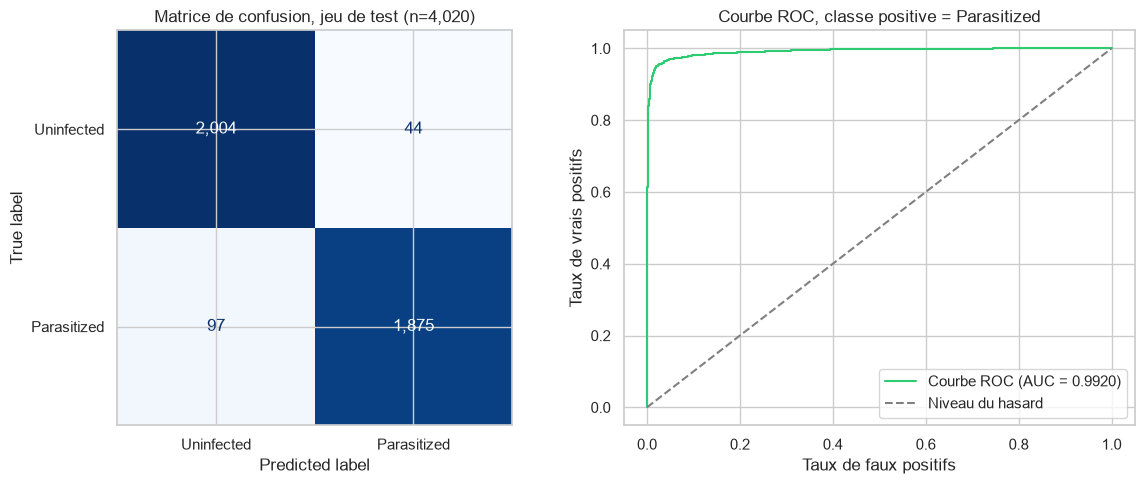

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Uninfected", "Parasitized"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False, values_format=",d"
)
axes[0].set_title(f"Matrice de confusion, jeu de test (n={len(y_true):,})")

fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[1].plot(fpr, tpr, label=f"Courbe ROC (AUC = {roc_auc:.4f})", color="#2ecc71")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Niveau du hasard")
axes[1].set_xlabel("Taux de faux positifs")
axes[1].set_ylabel("Taux de vrais positifs")
axes[1].set_title("Courbe ROC, classe positive = Parasitized")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

## 4. Sensibilité à la prévalence : à quoi ressembleraient VPP/VPN hors de ce dataset équilibré

Le jeu de test ci-dessus est artificiellement équilibré ~50/50 (une propriété du design original du dataset NIH), ce qui est très éloigné de la prévalence réelle d'un dépistage de terrain. La VPP et la VPN dépendent toutes deux de la prévalence, pas seulement de la sensibilité/spécificité, donc les valeurs de VPP/VPN mesurées ci-dessus ne sont valables que pour une population infectée à ~50% ; elles ne se transposent pas directement à un contexte de dépistage. En utilisant la sensibilité et la spécificité mesurées (qui, contrairement à la VPP/VPN, sont indépendantes de la prévalence) et la règle de Bayes, la cellule ci-dessous recalcule à quoi ressembleraient la VPP/VPN sous une hypothèse illustrative de faible prévalence, pour rendre cela concret plutôt que de l'affirmer dans l'abstrait.

In [7]:
def ppv_npv_at_prevalence(sensitivity, specificity, prevalence):
    ppv_p = (sensitivity * prevalence) / (sensitivity * prevalence + (1 - specificity) * (1 - prevalence))
    npv_p = (specificity * (1 - prevalence)) / (specificity * (1 - prevalence) + (1 - sensitivity) * prevalence)
    return ppv_p, npv_p


prevalence_scenarios = [0.50, 0.10, 0.02]  # 0.50 correspond a ce jeu de test ; 0.10 et 0.02 sont des hypotheses illustratives de niveau depistage, pas des valeurs mesurees
rows = []
for prev in prevalence_scenarios:
    ppv_p, npv_p = ppv_npv_at_prevalence(sensitivity, specificity, prev)
    rows.append({"assumed_prevalence": prev, "PPV": round(ppv_p, 4), "NPV": round(npv_p, 4)})

prevalence_table = pd.DataFrame(rows)
display(prevalence_table)

,assumed_prevalence,PPV,NPV
0,0.50,0.9779,0.9521
1,0.10,0.8310,0.9944
2,0.02,0.4746,0.9990


À sensibilité et spécificité fixées aux valeurs mesurées sur le jeu de test, la VPP chute nettement quand la prévalence supposée passe de 50 % à 2 %. C'est un comportement bayésien attendu, pas un défaut du modèle.

La conséquence est opérationnelle : en dépistage à faible prévalence, une prédiction positive demanderait une deuxième lecture de confirmation bien plus souvent que ne le laisse penser la VPP brute mesurée ici. C'est ce type d'écart entre performance sur benchmark et performance opérationnelle qu'une évaluation de la valeur médicale et opérationnelle doit rendre explicite.

## 5. Interprétabilité : cartes de saillance par gradient

Pour voir à quoi le modèle réagit, une carte de saillance par gradient simple (Simonyan et al., 2013) est calculée sur quelques images de test. On prend le gradient du score de la classe prédite par rapport à chaque pixel d'entrée. Cela met en évidence les pixels qui changeraient le plus la confiance du modèle s'ils étaient perturbés. L'implémentation utilise directement `torch.autograd`, sans bibliothèque d'interprétabilité externe. Elle fonctionne quelle que soit l'architecture retenue par le notebook 03, ce qui compte ici : ce choix n'est connu qu'une fois le notebook 03 exécuté.

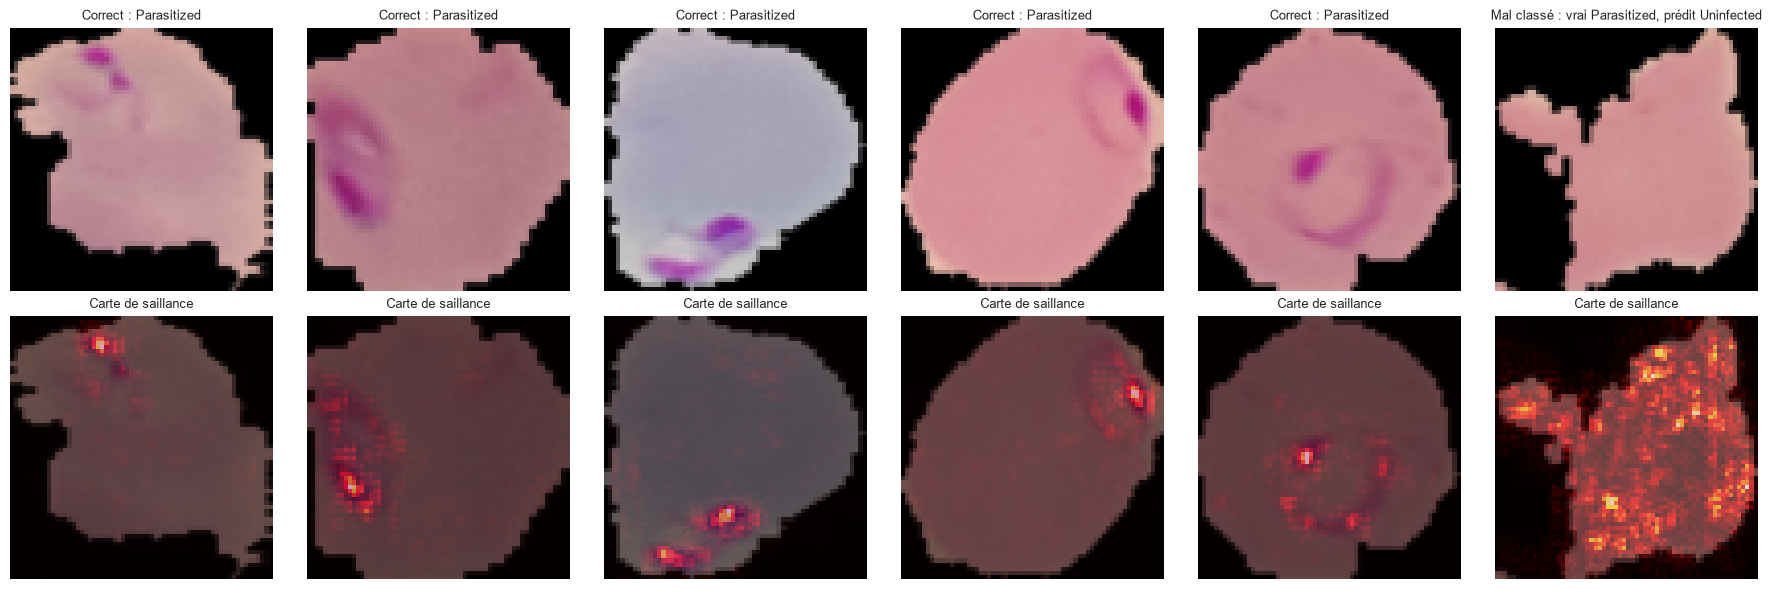

In [8]:
def compute_saliency(model, img_tensor, target_class):
    model.eval()
    img_tensor = img_tensor.clone().unsqueeze(0).to(DEVICE)
    img_tensor.requires_grad_(True)
    logits = model(img_tensor)
    score = logits[0, target_class]
    model.zero_grad()
    score.backward()
    saliency = img_tensor.grad.data.abs().squeeze(0)   # (3, H, W)
    saliency, _ = saliency.max(dim=0)                  # (H, W), max sur les canaux couleur
    return saliency.numpy()


def denormalize(tensor_img):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor_img * std + mean).clamp(0, 1)


# Quelques exemples Parasitized correctement classes, plus une erreur de classification si le jeu de test en contient une.
correct_parasitized_idx = np.where((y_true == POS_IDX) & (y_pred == POS_IDX))[0]
misclassified_idx = np.where(y_true != y_pred)[0]

rng = np.random.default_rng(42)
example_idx = list(rng.choice(correct_parasitized_idx, size=min(5, len(correct_parasitized_idx)), replace=False))
example_titles = ["Correct : Parasitized"] * len(example_idx)
if len(misclassified_idx) > 0:
    mis_i = int(rng.choice(misclassified_idx, size=1)[0])
    example_idx.append(mis_i)
    true_lbl = IDX_TO_LABEL[y_true[mis_i]]
    pred_lbl = IDX_TO_LABEL[y_pred[mis_i]]
    example_titles.append(f"Mal classé : vrai {true_lbl}, prédit {pred_lbl}")

n = len(example_idx)
fig, axes = plt.subplots(2, n, figsize=(3 * n, 6))
for col, (idx, title) in enumerate(zip(example_idx, example_titles)):
    img_tensor, label = test_dataset[idx]
    target_class = int(y_pred[idx])  # explique la prediction du modele lui-meme
    saliency = compute_saliency(model, img_tensor, target_class)

    img_np = denormalize(img_tensor).permute(1, 2, 0).numpy()
    axes[0, col].imshow(img_np)
    axes[0, col].set_title(title, fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].imshow(img_np)
    axes[1, col].imshow(saliency, cmap="hot", alpha=0.55)
    axes[1, col].set_title("Carte de saillance", fontsize=9)
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()

Les cartes de saillance se lisent directement. Ce qui compte est l'endroit où se concentre la zone chaude : à l'intérieur du corps cellulaire, ou bien sur les bords et dans le fond.

Dans le premier cas, le modèle regarde des zones de coloration du parasite plausibles. Dans le second, il s'appuie sur des artefacts, contour de la cellule ou texture du fond.

## 6. Discussion : valeur médicale et opérationnelle, limites, recommandations

### Valeur médicale et opérationnelle potentielle

Les résultats mesurés ci-dessus (Section 3) montrent un modèle capable de distinguer des cellules parasitées et saines sur ce jeu de test avec un niveau de performance élevé pour une tâche d'imagerie microscopique. Dans un contexte clinique réel, un tel outil ne devrait jamais fonctionner comme un diagnostic autonome. Sa valeur se situe plutôt dans deux usages concrets :

* **Aide au tri (pre-screening) :** faire remonter en priorité les lames ou zones suspectes pour lecture par un technicien, utile dans des contextes de forte charge d'échantillons ou de personnel qualifié limité.
* **Second lecteur :** apporter un avis indépendant en complément de la lecture humaine, pour réduire le risque d'erreur d'attention sur de longues séries de lames, sans remplacer la décision du biologiste.

La sensibilité mesurée (Section 3) est la métrique la plus critique cliniquement : rater une infection réelle (faux négatif) a des conséquences plus graves qu'un faux positif, qui se traduit seulement par une vérification supplémentaire. La section 4 montre cependant qu'à une prévalence réaliste de terrain, bien plus faible que les 50% de ce jeu de données, la valeur prédictive positive chute nettement : un résultat positif du modèle nécessiterait donc une confirmation systématique avant toute décision clinique.

### Limites réelles de cette évaluation

* **Un seul type de microscope et de coloration :** toutes les images proviennent du même protocole (frottis mince, même centre hospitalier, même numérisation). Rien ne garantit une performance équivalente sur des lames d'un autre laboratoire, d'un autre scanner ou d'une autre coloration.
* **Aucune validation externe :** le test set provient de la même distribution que les données d'entraînement (même source, split image par image). Une vraie validation clinique demanderait un jeu de données totalement indépendant, idéalement multi-centrique.
* **Prévalence artificiellement équilibrée :** comme discuté en Section 4, le 50/50 de ce dataset ne reflète pas la prévalence réelle du paludisme en contexte de dépistage, ce qui change fortement l'interprétation opérationnelle des valeurs prédictives.
* **Split par patient (200 patients : 140 / 30 / 30) :** le split est groupé par identifiant de patient, donc aucun patient du test n'a été vu à l'entraînement. Une première version, faite au niveau image, donnait des métriques quasi identiques (accuracy 96,1 % dans les deux cas) : la fuite image/patient n'expliquait pas la performance. Avec seulement 30 patients dans le test, l'incertitude reste néanmoins large.
* **Marquage réglementaire :** un usage clinique réel nécessiterait un marquage CE-IVD (dispositif médical de diagnostic in vitro), avec toute la documentation, les essais cliniques et le suivi post-marché associés. Ce notebook est un travail de faisabilité technique, pas un dispositif validé.

### Recommandations concrètes pour la suite

1. Constituer ou obtenir un second jeu de données, idéalement d'un autre centre/microscope, pour une validation externe avant toute conclusion sur la généralisation.
2. Estimer l'incertitude de ces métriques (validation croisée groupée par patient ou bootstrap par patient), le test ne comptant que 30 patients.
3. Étudier la performance sous des scénarios de prévalence réalistes (au lieu du calcul illustratif de la Section 4), en construisant un jeu de test délibérément déséquilibré.
4. Définir avec les biologistes un seuil de décision (threshold sur la probabilité) adapté à l'usage visé (tri vs second lecteur), plutôt que le seuil par défaut de 0.5 utilisé ici.
5. Si le projet avance vers un usage clinique, engager le processus de qualification réglementaire (CE-IVD) en parallèle du développement technique, pas après.